# Notebook 01: Dataset Overview & Target Labels EDA
## RSNA Knee Abnormality Detection (KneeVision-AI)

This notebook provides exploratory data analysis (EDA) of the **RSNA Knee Abnormality Detection** challenge tabular metadata:
1. **Study-level Metadata (`train.csv`, `test.csv`)**: Exploring patient studies and target labels.
2. **Label Distributions & Class Imbalance**: Evaluating positive prevalence across the 12 clinical knee abnormality targets.
3. **Multi-label Co-occurrence**: Correlation heatmaps and co-occurring pathology patterns.
4. **Series-level Metadata (`train_series.csv`)**: Analyzing series counts per study, anatomical planes (`Sagittal`, `Coronal`, `Axial`), and MRI contrasts (`Fluid_Sensitive`, `Fat_Suppression`).
5. **Leak-free 5-Fold Multilabel Stratified Split**: Generating and validating cross-validation folds.


In [1]:
import os
import sys

# Ensure repository root is in python path
for root_cand in ['.', '..', os.path.abspath(os.path.join(os.getcwd(), '..'))]:
    if os.path.exists(os.path.join(root_cand, 'src')):
        if os.path.abspath(root_cand) not in sys.path:
            sys.path.insert(0, os.path.abspath(root_cand))
        break

# Resolve DATA_DIR whether running from workspace root or notebooks/
DATA_DIR = None
for cand in [
    '../Datasets/rsna-knee-abnormality-detection',
    '../../Datasets/rsna-knee-abnormality-detection',
    os.path.expanduser('~/net/Datasets/rsna-knee-abnormality-detection'),
    '/home/AQ44130/net/Datasets/rsna-knee-abnormality-detection'
]:
    if os.path.exists(cand):
        DATA_DIR = os.path.abspath(cand)
        break

print(f"✓ Resolved DATA_DIR: {DATA_DIR}")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10


✓ Resolved DATA_DIR: /data/users/sukesh/Datasets/rsna-knee-abnormality-detection


## 1. Load Tabular Metadata

In [2]:
train_df = pd.read_csv(f"{DATA_DIR}/train.csv")
train_series_df = pd.read_csv(f"{DATA_DIR}/train_series.csv")
test_df = pd.read_csv(f"{DATA_DIR}/test.csv")
test_series_df = pd.read_csv(f"{DATA_DIR}/test_series.csv")
sample_sub = pd.read_csv(f"{DATA_DIR}/sample_submission.csv")

print(f"Train Studies: {len(train_df):,}")
print(f"Train Series:  {len(train_series_df):,}")
print(f"Test Studies:  {len(test_df):,}")
print(f"Test Series:   {len(test_series_df):,}")


Train Studies: 4,407
Train Series:  24,371
Test Studies:  3
Test Series:   15


## 2. Abnormality Targets & Label Distribution Analysis

In [3]:
TARGET_COLUMNS = [
    'ACL', 'MCL', 'Medial Meniscus', 'Lateral Meniscus',
    'Medial OA', 'Lateral OA', 'PF OA', 'Effusion',
    'Synovitis', "Baker's", 'Contusion', 'Fracture'
]

# Separate labeled vs unlabeled (weak report only) studies
labeled_mask = train_df[TARGET_COLUMNS].notnull().any(axis=1)
df_labeled = train_df[labeled_mask].copy()
df_unlabeled = train_df[~labeled_mask].copy()

print(f"Studies with Ground Truth Binary Labels: {len(df_labeled):,} ({len(df_labeled)/len(train_df)*100:.1f}%)")
print(f"Studies with Weak Radiology Reports only:  {len(df_unlabeled):,} ({len(df_unlabeled)/len(train_df)*100:.1f}%)")


Studies with Ground Truth Binary Labels: 58 (1.3%)
Studies with Weak Radiology Reports only:  4,349 (98.7%)


,Abnormality,Positive,Negative,Total Labeled,Prevalence (%)
7,Effusion,35,23,58,60.3
8,Synovitis,27,31,58,46.6
2,Medial Meniscus,26,32,58,44.8
0,ACL,24,34,58,41.4
3,Lateral Meniscus,23,35,58,39.7
6,PF OA,21,37,58,36.2
10,Contusion,19,39,58,32.8
11,Fracture,18,40,58,31.0
4,Medial OA,15,43,58,25.9
9,Baker's,12,46,58,20.7


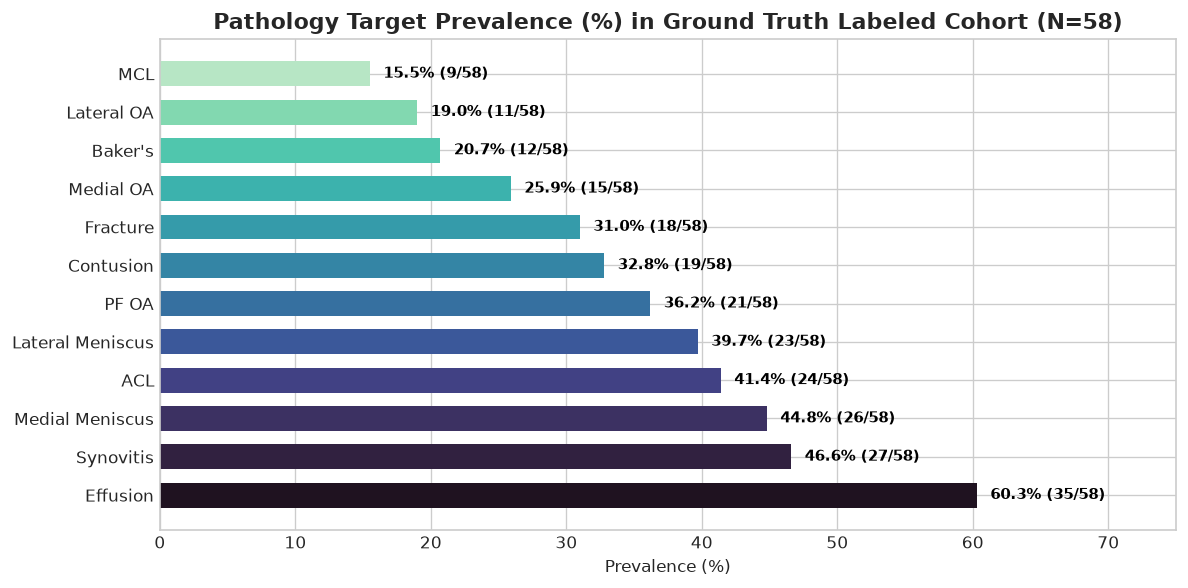

In [4]:
# Calculate target frequencies and prevalence in labeled cohort
stats = []
for col in TARGET_COLUMNS:
    pos = int((df_labeled[col] == 1.0).sum())
    neg = int((df_labeled[col] == 0.0).sum())
    total = pos + neg
    prev = (pos / total * 100) if total > 0 else 0
    stats.append({
        'Abnormality': col,
        'Positive': pos,
        'Negative': neg,
        'Total Labeled': total,
        'Prevalence (%)': round(prev, 1)
    })

stats_df = pd.DataFrame(stats).sort_values(by='Prevalence (%)', ascending=False)
display(stats_df)

# Plot prevalence bar chart
fig, ax = plt.subplots(figsize=(10, 5))
colors = sns.color_palette("mako", len(stats_df))
bars = ax.barh(stats_df['Abnormality'], stats_df['Prevalence (%)'], color=colors, height=0.65)
ax.set_title('Pathology Target Prevalence (%) in Ground Truth Labeled Cohort (N=58)', fontsize=13, fontweight='bold')
ax.set_xlabel('Prevalence (%)')
for bar, (_, row) in zip(bars, stats_df.iterrows()):
    w = bar.get_width()
    ax.text(w + 1.0, bar.get_y() + bar.get_height() / 2, f"{w:.1f}% ({int(row['Positive'])}/{int(row['Total Labeled'])})",
            ha='left', va='center', fontsize=9, color='black', fontweight='bold')
plt.xlim(0, 75)
plt.tight_layout()
plt.show()


## 3. Pathology Co-occurrence & Correlation Matrix

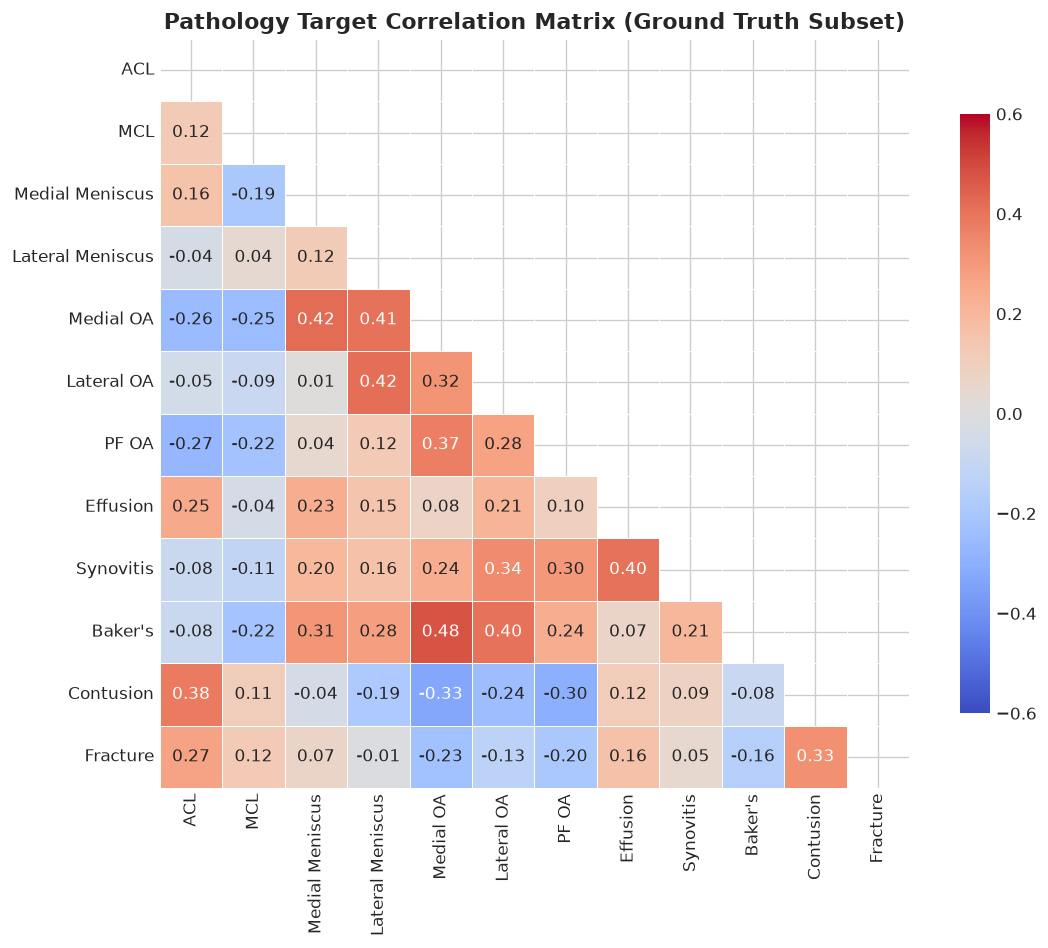

In [5]:
# Compute multi-label correlation matrix
corr_matrix = df_labeled[TARGET_COLUMNS].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-0.6, vmax=0.6,
            mask=mask, square=True, linewidths=0.5, cbar_kws={"shrink": .8}, ax=ax)
ax.set_title('Pathology Target Correlation Matrix (Ground Truth Subset)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## 4. Series-Level Breakdown (Anatomical Planes & Contrasts)

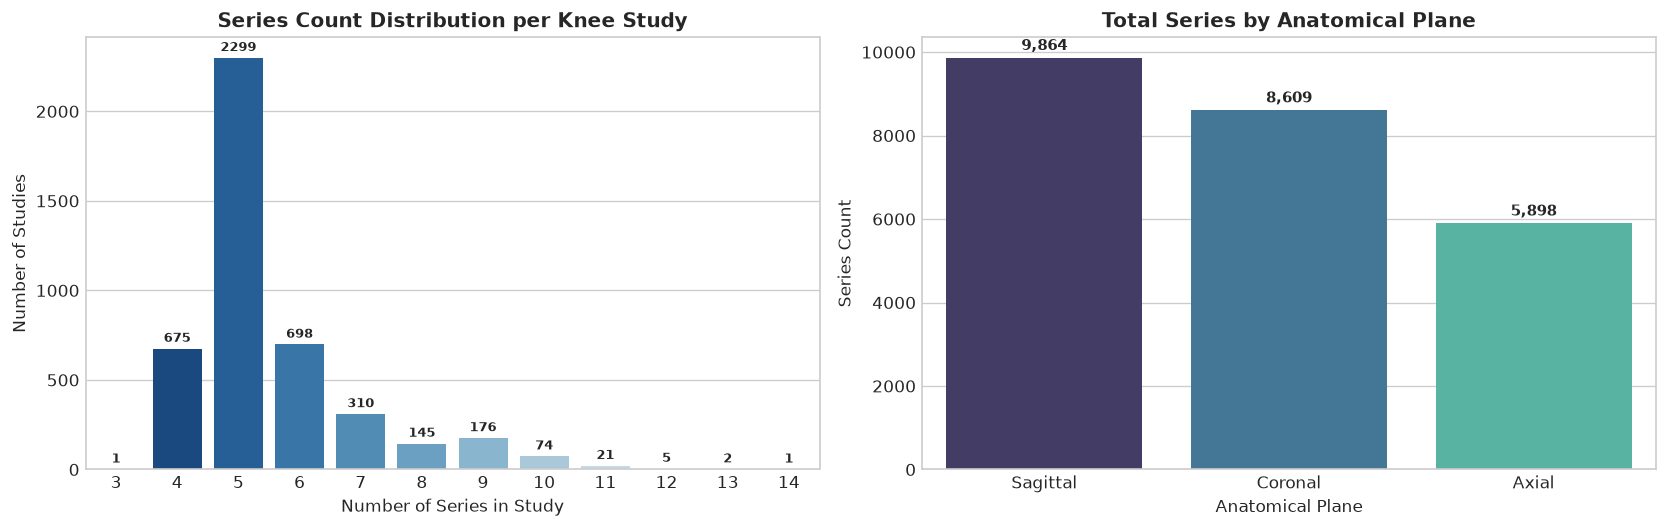

In [6]:
# Series per study distribution
series_per_study = train_series_df.groupby('StudyInstanceUID').size()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4.5))

# Plot 1: Series Count Histogram
sns.countplot(x=series_per_study.values, hue=series_per_study.values, palette='Blues_r', legend=False, ax=ax1)
ax1.set_title('Series Count Distribution per Knee Study', fontsize=12, fontweight='bold')
ax1.set_xlabel('Number of Series in Study')
ax1.set_ylabel('Number of Studies')
for p in ax1.patches:
    h = p.get_height()
    if h > 0:
        ax1.annotate(f"{int(h)}", (p.get_x() + p.get_width()/2, h + 20),
                     ha='center', va='bottom', fontsize=8, fontweight='bold')

# Plot 2: Anatomical Planes
plane_counts = train_series_df['Anatomical_Plane'].value_counts()
sns.barplot(x=plane_counts.index, y=plane_counts.values, hue=plane_counts.index, palette='mako', legend=False, ax=ax2)
ax2.set_title('Total Series by Anatomical Plane', fontsize=12, fontweight='bold')
ax2.set_xlabel('Anatomical Plane')
ax2.set_ylabel('Series Count')
for p in ax2.patches:
    ax2.annotate(f"{int(p.get_height()):,}", (p.get_x() + p.get_width()/2, p.get_height() + 100),
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()


## 5. Leak-Free 5-Fold Multilabel Stratified Split Generation

In [7]:
from iterstrat.ml_stratifiers import MultilabelStratifiedKFold

# Ensure reproducible 5-fold partition
SEED = 42
N_SPLITS = 5

mskf = MultilabelStratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
X = df_labeled["StudyInstanceUID"].values
Y = df_labeled[TARGET_COLUMNS].fillna(0).values

df_labeled["fold"] = -1
for fold_idx, (_, val_idx) in enumerate(mskf.split(X, Y)):
    df_labeled.iloc[val_idx, df_labeled.columns.get_loc("fold")] = fold_idx

# Partition unlabeled studies evenly across folds
df_unlabeled["fold"] = np.random.RandomState(SEED).randint(0, N_SPLITS, size=len(df_unlabeled))

# Master splits dataframe
splits_df = pd.concat([df_labeled, df_unlabeled], ignore_index=True)
os.makedirs("data", exist_ok=True)
splits_df.to_csv("data/splits_5fold.csv", index=False)

print(f"Master splits generated successfully with {N_SPLITS} folds.")
display(splits_df.groupby(['fold', splits_df[TARGET_COLUMNS].notnull().any(axis=1)]).size().unstack().rename(columns={False: 'Unlabeled', True: 'Labeled'}))


Master splits generated successfully with 5 folds.


,Unlabeled,Labeled
fold,,
0,892,12
1,834,10
2,853,12
3,876,11
4,894,13
